In [1]:
import sys
import os

backend_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if backend_path not in sys.path:
    sys.path.insert(0, backend_path)

print(f"Backend path: {backend_path}")
print("Ready ✅")

Backend path: /home/rishabh/Documents/AI Projects
Ready ✅


In [2]:
from app.ml.preprocessing.text_cleaner import clean_text, extract_experience_years, preprocess

sample = """
Senior Python Developer with 5+ years of experience.
Email: john@email.com | LinkedIn: linkedin.com/in/john
Skills: Python, FastAPI, PostgreSQL, Docker, AWS
Led a team of 5 engineers building REST APIs.
"""

result = preprocess(sample)
print('=== Preprocessing Result ===')
print(f'Word count:  {result["word_count"]}')
print(f'Experience:  {result["experience_years"]} years')
print(f'Cleaned:\n{result["cleaned_text"][:200]}')

/home/rishabh/.local/lib/python3.10/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/rishabh/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):


=== Preprocessing Result ===
Word count:  29
Experience:  5 years
Cleaned:
senior python developer with 5 years of experience email linkedin linkedin com in john skills python fastapi postgresql docker aws led a team of 5 engineers building rest apis


In [3]:
from app.ml.preprocessing.skill_extractor import extract_skills, get_skill_gap

resume_text = 'Python FastAPI PostgreSQL Docker AWS Redis Git machine learning'
job_text = 'Python FastAPI PostgreSQL Docker AWS Kubernetes'

resume_skills = extract_skills(resume_text)
job_skills = extract_skills(job_text)
gap = get_skill_gap(resume_skills, job_skills)

print('=== Skill Analysis ===')
print(f'Resume skills: {resume_skills}')
print(f'Job skills:    {job_skills}')
print(f'Matching:      {gap["matching_skills"]}')
print(f'Missing:       {gap["missing_skills"]}')
print(f'Match %:       {gap["match_percentage"]}%')

=== Skill Analysis ===
Resume skills: ['python', 'fastapi', 'postgresql', 'redis', 'docker', 'aws', 'git', 'machine learning']
Job skills:    ['python', 'fastapi', 'postgresql', 'docker', 'kubernetes', 'aws']
Matching:      ['aws', 'fastapi', 'postgresql', 'python', 'docker']
Missing:       ['kubernetes']
Match %:       83.33%


Loading embedder: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding shape: (4, 384)


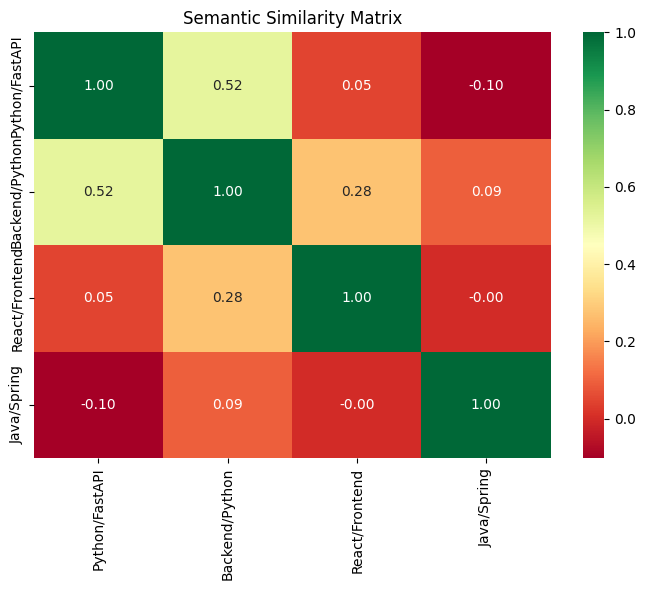

Preprocessing Complete ✅


In [4]:
from app.ml.features.embeddings import SemanticEmbedder
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

embedder = SemanticEmbedder()

texts = [
    'Python developer FastAPI PostgreSQL',
    'Backend engineer Python REST APIs',
    'Frontend React JavaScript developer',
    'Java Spring Boot microservices'
]
labels = ['Python/FastAPI', 'Backend/Python', 'React/Frontend', 'Java/Spring']

embeddings = embedder.encode(texts)
sim_matrix = cosine_similarity(embeddings)

print(f'Embedding shape: {embeddings.shape}')

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    sim_matrix,
    xticklabels=labels,
    yticklabels=labels,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    ax=ax
)
ax.set_title('Semantic Similarity Matrix')
plt.tight_layout()
plt.show()
print('Preprocessing Complete ✅')